# Diabetes Dataset

### Atributos
- Os dados contém 9 atributos, sendo eles:
    - **Pregnancies:** Quantidade de vezes que a paciente já esteve grávida;
    - **Glucose:** Concentração de glicose no plasma 2 horas após um teste de tolerância à glicose oral;
    - **BloodPressure:** Pressão arterial diastólica (em mmHg);
    - **SkinThickness:** Espessura da dobra cutânea no tríceps (em milímetros);
    - **Insulin:** Nível de insulina sérica após 2 horas de teste (em µU/mL);
    - **BMI:** Índice de Massa Corporal (IMC);
    - **DiabetesPedigreeFunction:** Probabilidade hereditária de diabetes com base no histórico familiar;
    - **Age:** Idade da paciente (em anos);
    - **Outcome:** Resultado do paciente: 1 - tem diabetes; 0 - paciente não tem diabétes.

### Quantidade de Instâncias
- O dataset apresenta 768 amostras;

### Origem e Datas
- Os dados constados no dataset foram adaptados das pesquisar do National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) e publicados no site kaggle.com. Contém dados do ano de 2023 ~ 2024.

### Licença
- O dataset é licenciado pelo MIT e tem seu uso livre principalmente utilizado em pesquisas de aprendizado de máquina sobre saúde e diagnósticos médicos.

### Discursões Éticas
- A análise explorativa do dataset não apresentar nenhuma questão moral negativa relacionada as pessoas que tiveram seus dados coletados. Não há informações que possam idenficar ou associar diretamente a pessoa e os dados coletados. 
    Por se tratar de uma análise relacionada diretamentea diabetes, a análise deve ser feita tomando como base as melhores práticas com a finalidade de encontrar resultados válidos que não compromentam a saúde de pessoas afetadas pela doeça.


In [48]:
# bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [49]:
# carregamento inicial dos dados
df = pd.read_csv("../data/raw/diabetes_dataset.csv", encoding='latin-1')

In [50]:
# visualização inicial
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [51]:
# visualização das informações principais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [52]:
# validando a existencia valores ausentes ou falsos zeros
df.isnull().sum()

cols_with_invalid_zero = ["Glucose", "BloodPressure", "Insulin", "BMI"]
(df[cols_with_invalid_zero] <= 0).sum()

Glucose            5
BloodPressure     35
Insulin          374
BMI               11
dtype: int64

In [53]:
# estatísticas descritivas
df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [54]:
# removendo linhas com valores inválidos
with_removed_zeros = df.copy()

for col in cols_with_invalid_zero:
    with_removed_zeros = with_removed_zeros[with_removed_zeros[col] > 0]

with_removed_zeros.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 3 to 765
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               392 non-null    int64  
 1   Glucose                   392 non-null    int64  
 2   BloodPressure             392 non-null    int64  
 3   SkinThickness             392 non-null    int64  
 4   Insulin                   392 non-null    int64  
 5   BMI                       392 non-null    float64
 6   DiabetesPedigreeFunction  392 non-null    float64
 7   Age                       392 non-null    int64  
 8   Outcome                   392 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 30.6 KB


In [55]:
# Calcular Z-score para todas as colunas numéricas
z_scores = np.abs(stats.zscore(with_removed_zeros.select_dtypes(include=[np.number])))

# Criar máscara para linhas sem outliers
mask = (z_scores < 3).all(axis=1)

# Remover outliers
df_no_outliers = with_removed_zeros[mask]

print("Linhas originais:", with_removed_zeros.shape[0])
print("Linhas sem outliers:", df_no_outliers.shape[0])

Linhas originais: 392
Linhas sem outliers: 365


In [56]:

# Supondo que seu DataFrame final seja chamado df
df_no_outliers.to_csv("../data/processed/diabetes_dataset.csv", index=False)

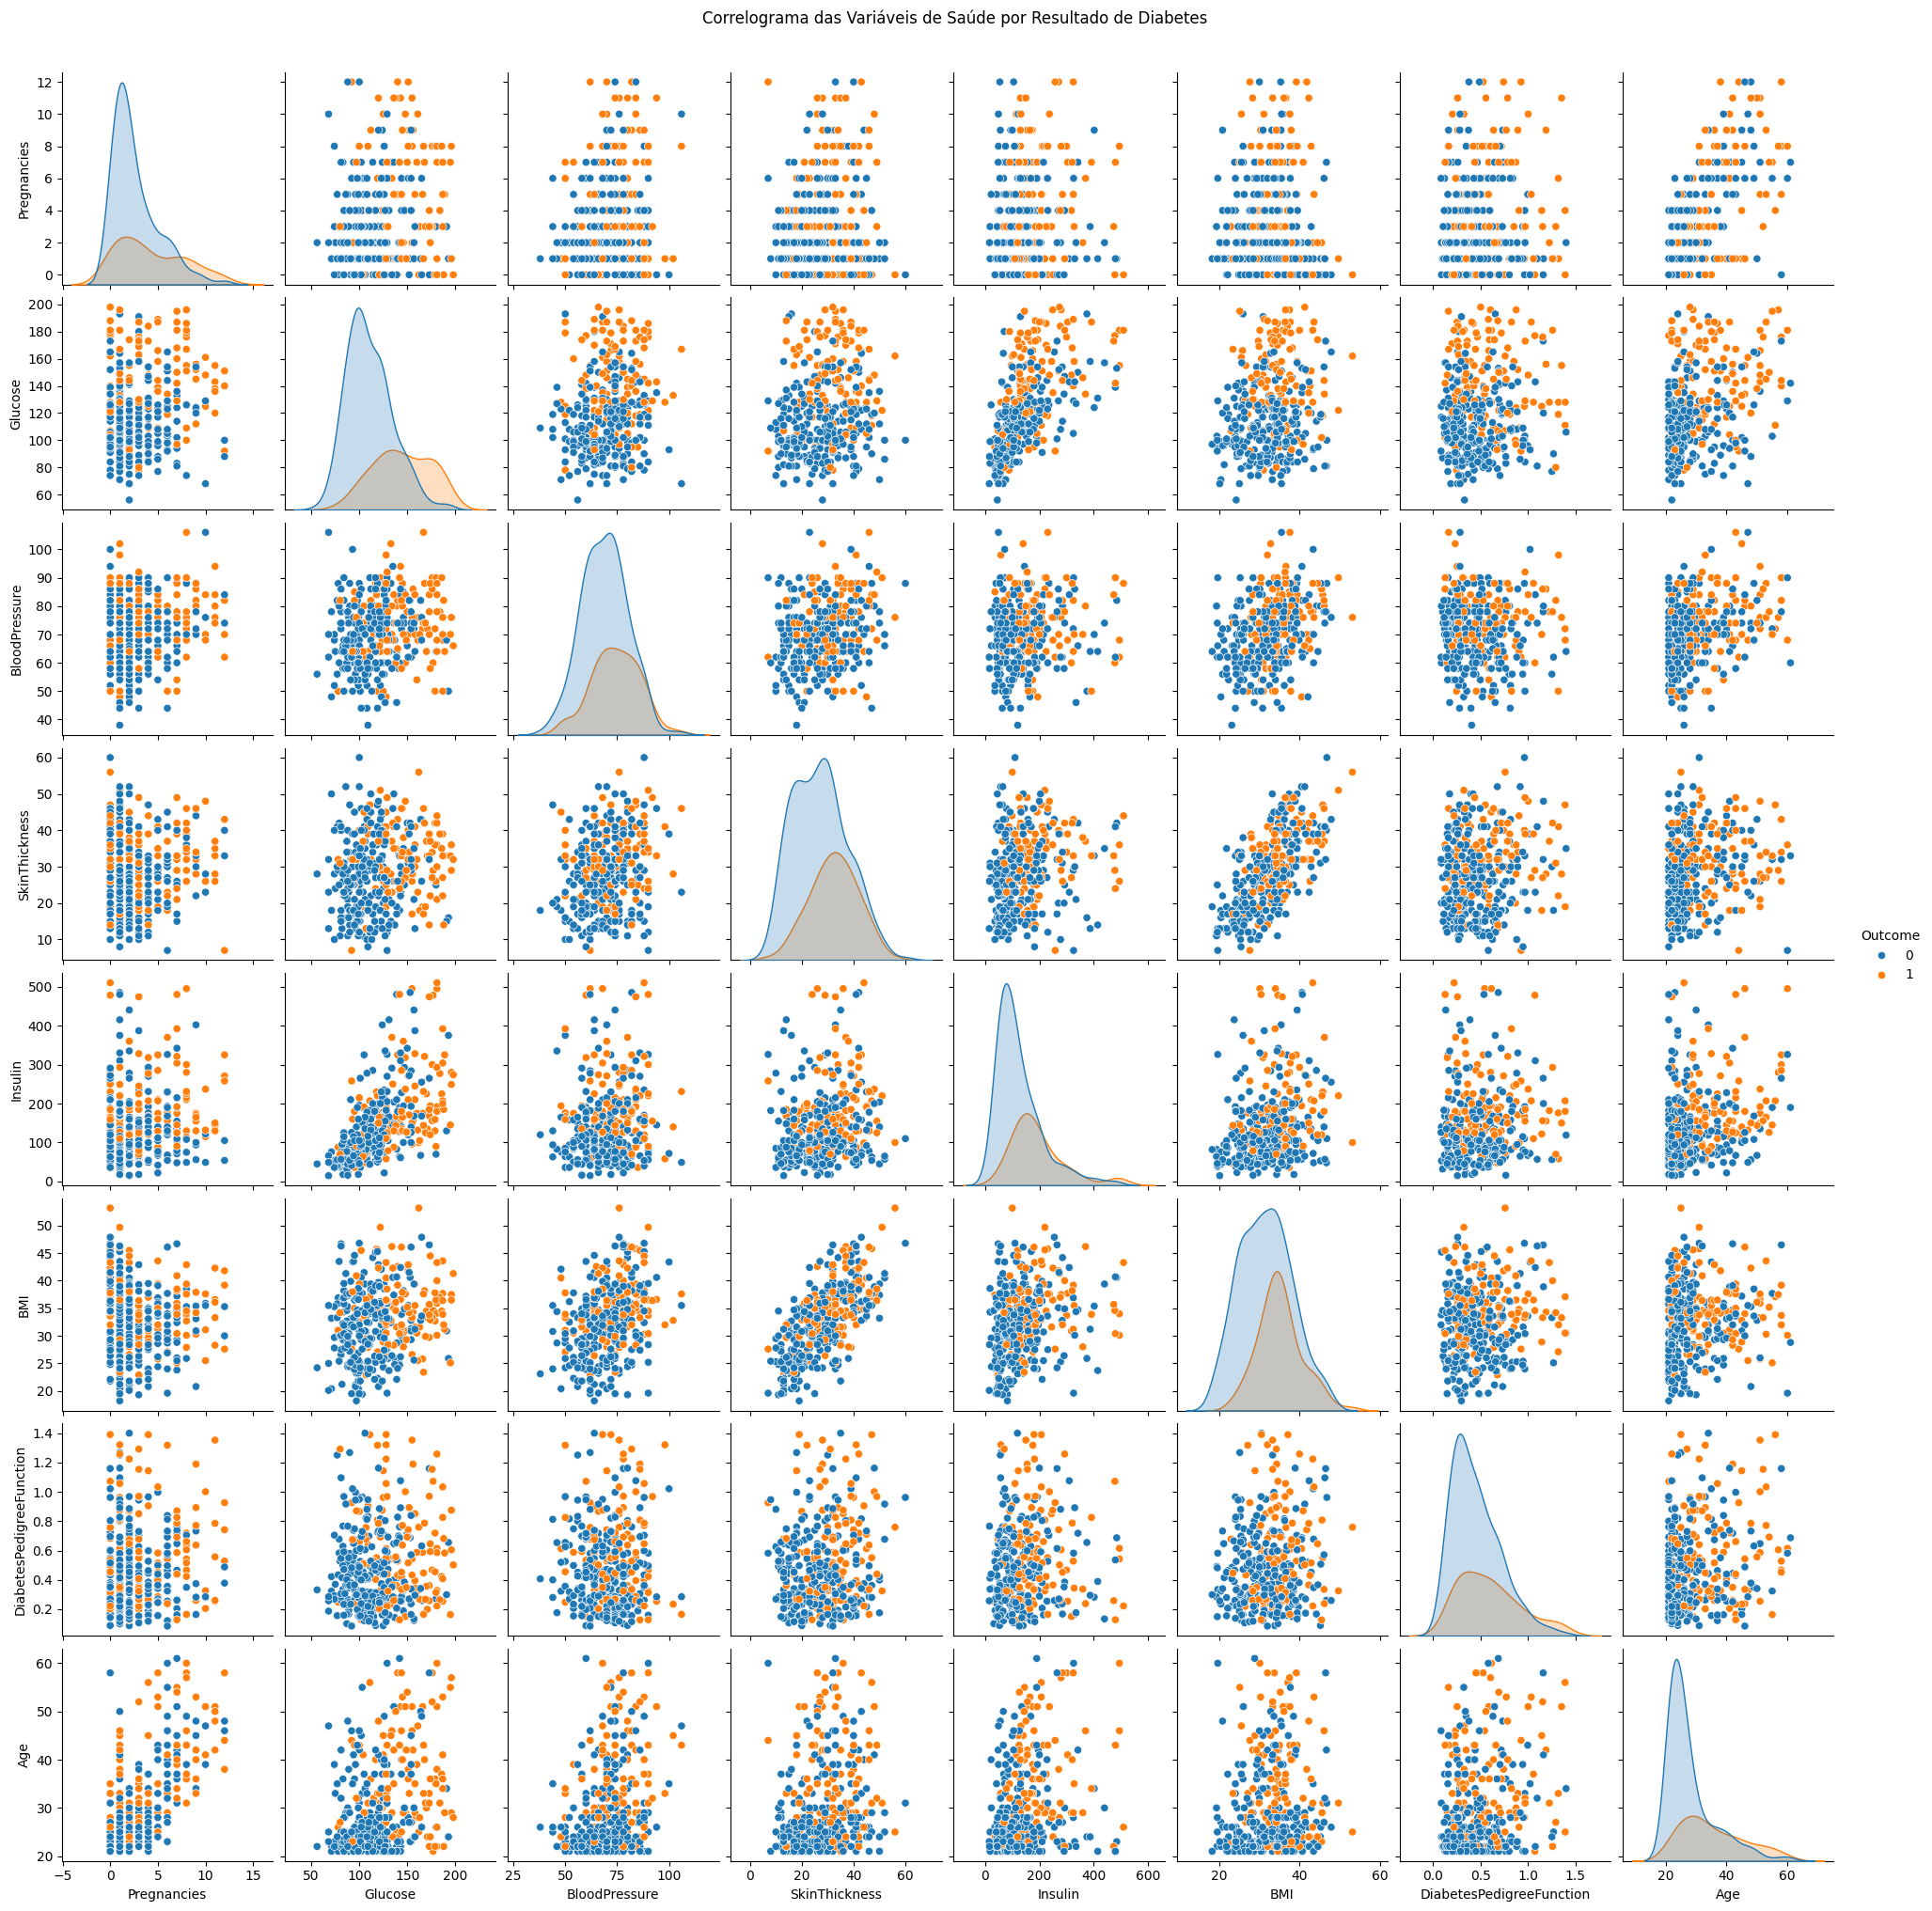

In [58]:
sns.pairplot(df_no_outliers, hue="Outcome", diag_kind='kde')
plt.suptitle("Correlograma das Variáveis de Saúde por Resultado de Diabetes", y=1.02)
plt.show()

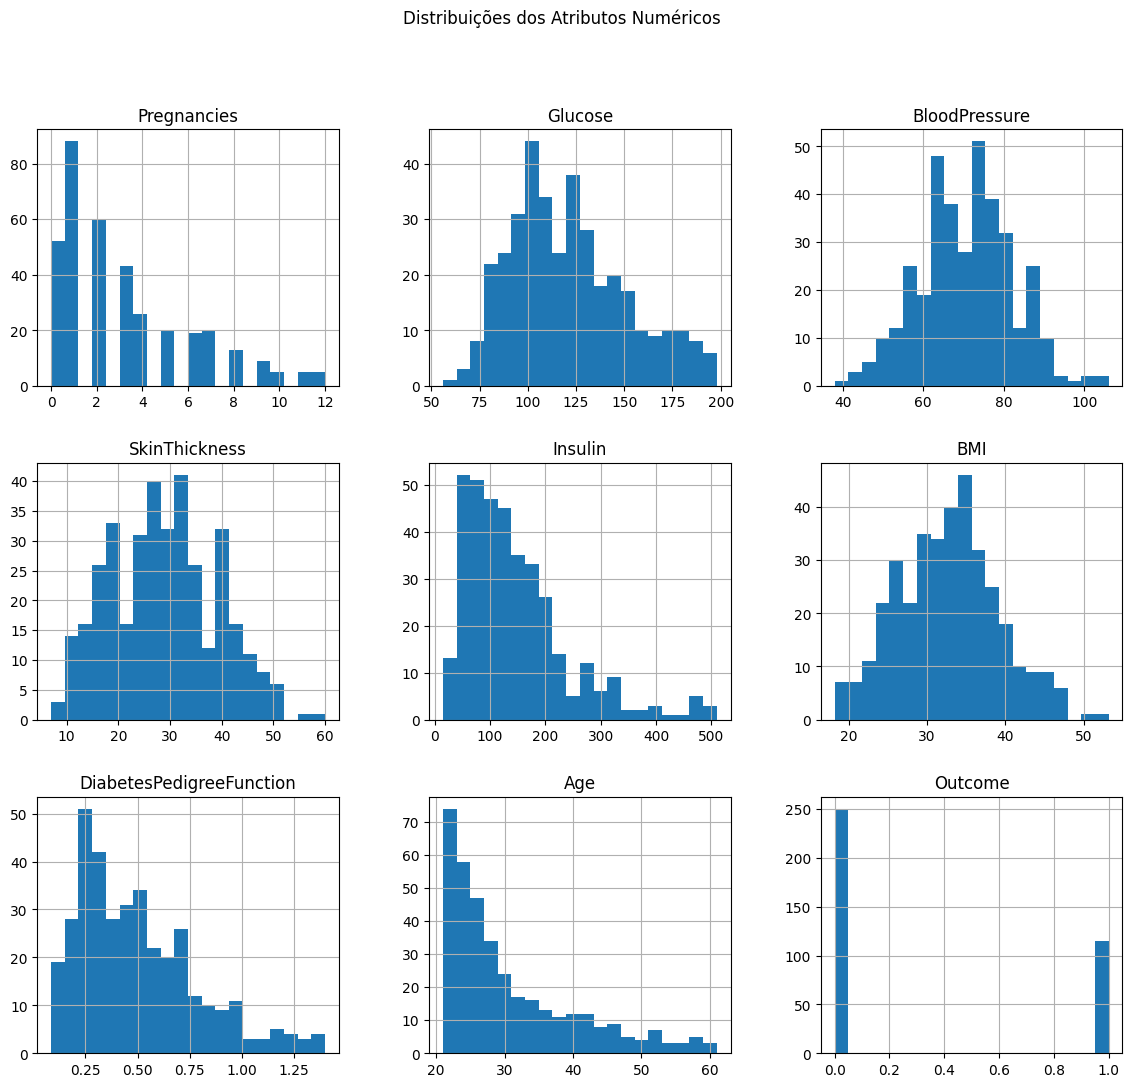

In [59]:
num_cols = df_no_outliers.select_dtypes(include=[np.number]).columns

df_no_outliers[num_cols].hist(figsize=(14, 12), bins=20)
plt.suptitle("Distribuições dos Atributos Numéricos")
plt.show()

<Figure size 1400x1000 with 0 Axes>

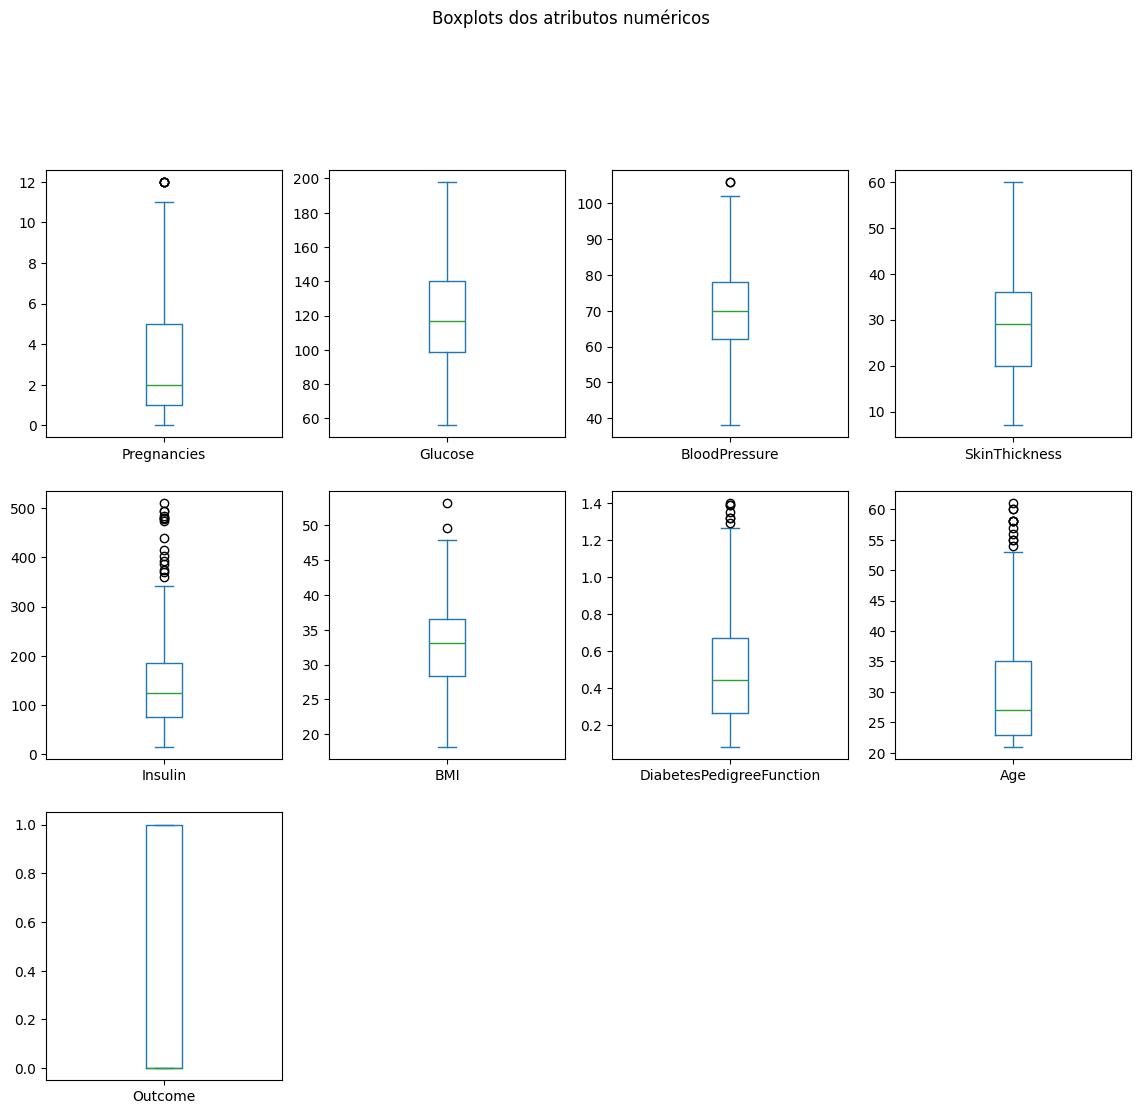

In [60]:
plt.figure(figsize=(14, 10))
df_no_outliers[num_cols].plot(kind="box", subplots=True, layout=(4, 4), figsize=(14,16))
plt.suptitle("Boxplots dos atributos numéricos")
plt.show()

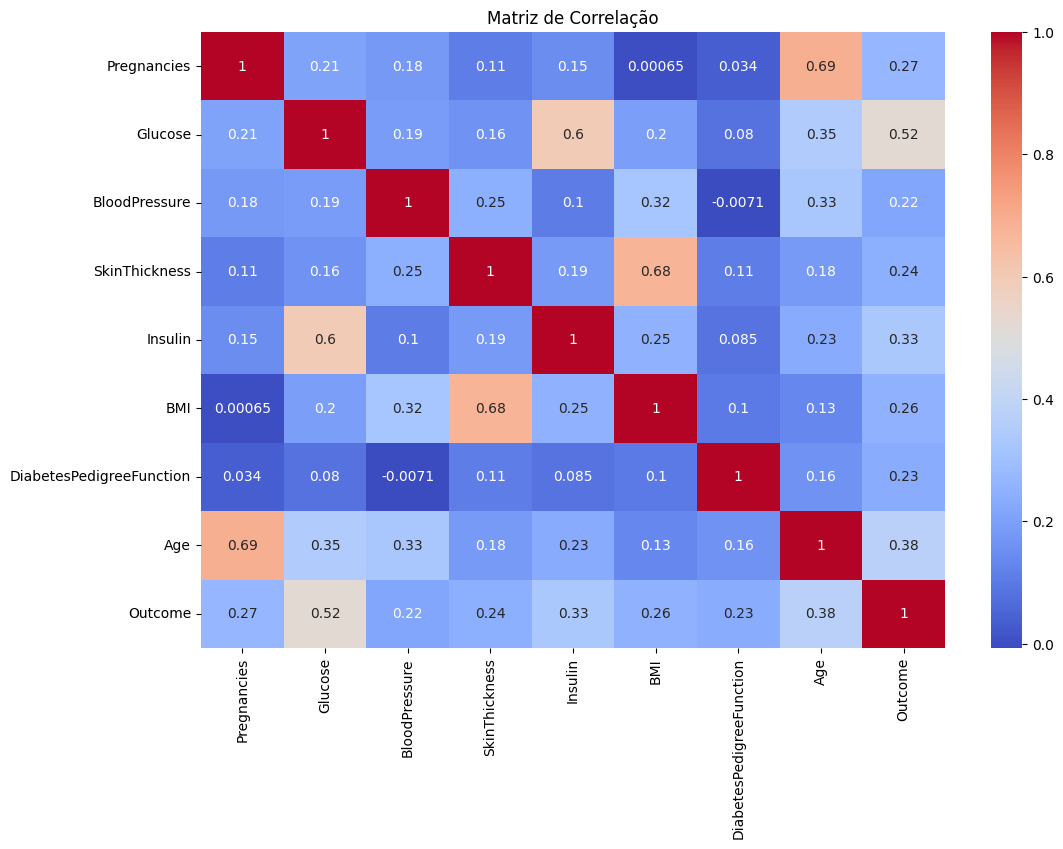

In [61]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_no_outliers[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()